<a href="https://colab.research.google.com/github/Neuocell/textgrad/blob/main/examples/notebooks/Tutorial-Test-Time-Loss-for-Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tutorial: Defining a new test-time loss and optimizing code.

![TextGrad](https://github.com/vinid/data/blob/master/logo_full.png?raw=true)

An autograd engine -- for textual gradients!

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zou-group/TextGrad/blob/main/examples/notebooks/Prompt-Optimization.ipynb)
[![GitHub license](https://img.shields.io/badge/License-MIT-blue.svg)](https://lbesson.mit-license.org/)
[![Arxiv](https://img.shields.io/badge/arXiv-2406.07496-B31B1B.svg)](https://arxiv.org/abs/2406.07496)
[![Documentation Status](https://readthedocs.org/projects/textgrad/badge/?version=latest)](https://textgrad.readthedocs.io/en/latest/?badge=latest)
[![PyPI - Python Version](https://img.shields.io/pypi/pyversions/textgrad)](https://pypi.org/project/textgrad/)
[![PyPI](https://img.shields.io/pypi/v/textgrad)](https://pypi.org/project/textgrad/)

**Objectives:**

* In this tutorial, we will do a quick walkthrough around how to define a simple test time loss in TextGrad and optimize a variable of interest.

**Requirements:**

* You need to have an OpenAI API key to run this tutorial. This should be set as an environment variable as OPENAI_API_KEY.

We first define some utilities and a set of test cases.

In [2]:
!pip install textgrad # you might need to restart the notebook after installing textgrad
import os
from google.colab import userdata

# 1. 设置 API Key（确保你已经在 Secrets 里存了 OPENAI_API_KEY）
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# 2. 设置中转站地址
# 注意：通常需要以 /v1 结尾，例如 https://api.yourproxy.com/v1
os.environ["OPENAI_BASE_URL"] = "https://api2.aigcbest.top/v1"
import textgrad as tg
import random
import time

### Utilities to run the code, and test cases

In [6]:
# We'll use below utilities to run a python function.
from IPython.core.interactiveshell import InteractiveShell

def run_function_in_interpreter(func_code):
    # raise Exception("This function will run the code returned by GPT-4o. Remove this if you'd like to run the code!")
    interpreter = InteractiveShell.instance()

    interpreter.run_cell(func_code, store_history=False, silent=True)

    func_name = func_code.split("def ")[1].split("(")[0].strip()
    func = interpreter.user_ns[func_name]

    return func


def test_longest_increasing_subsequence(fn):
    nums = [10, 22, 9, 33, 21, 50, 41, 60]
    assert fn(nums) == 5

    nums = [7, 2, 1, 3, 8, 4, 9, 6, 5]
    assert fn(nums) == 4

    nums = [5, 4, 3, 2, 1]
    assert fn(nums) == 1

    nums = [1, 2, 3, 4, 5]
    assert fn(nums) == 5

    nums = [3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5]
    assert fn(nums) == 4

    nums = [10, 9, 2, 5, 3, 7, 101, 18]
    assert fn(nums) == 4

    nums = [0, 8, 4, 12, 2, 10, 6, 14, 1, 9, 5, 13, 3, 11, 7, 15]
    assert fn(nums) == 6

    nums = [7, 7, 7, 7, 7, 7, 7]
    assert fn(nums) == 1

    nums = [20, 25, 47, 35, 56, 68, 98, 101, 212, 301, 415, 500]
    assert fn(nums) == 11

    nums = [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
    assert fn(nums) == 1

    print("All test cases passed!")

## Problem: Improving a code snippet.
We have a simple problem, and an initial solution that does not run quite fast. We first test this solution and look at the wall clock time.

In [4]:
problem_text = """Longest Increasing Subsequence (LIS)

Problem Statement:
Given a sequence of integers, find the length of the longest subsequence that is strictly increasing. A subsequence is a sequence that can be derived from another sequence by deleting some or no elements without changing the order of the remaining elements.

Input:
The input consists of a list of integers representing the sequence.

Output:
The output should be an integer representing the length of the longest increasing subsequence."""

initial_solution = """
def longest_increasing_subsequence(nums):
    n = len(nums)
    dp = [1] * n

    for i in range(1, n):
        for j in range(i):
            if nums[i] > nums[j]:
                dp[i] = max(dp[i], dp[j] + 1)

    max_length = max(dp)
    lis = []

    for i in range(n - 1, -1, -1):
        if dp[i] == max_length:
            lis.append(nums[i])
            max_length -= 1

    return len(lis[::-1])
"""

# Generate a random test case
def generate_random_test_case(size, min_value, max_value):
    return [random.randint(min_value, max_value) for _ in range(size)]

# Test the function with a random test case
size = 10000  # Adjust the size as needed
min_value = 1
max_value = 1000

nums = generate_random_test_case(size, min_value, max_value)


In [7]:
longest_increasing_subsequence = run_function_in_interpreter(initial_solution)

start_time = time.time()
lis = longest_increasing_subsequence(nums)
end_time = time.time()

print(f"Test Case Size: {size}")
print(f"Longest Increasing Subsequence Length: {lis}")
print(f"Runtime: {end_time - start_time:.5f} seconds")

# Test for all test cases
test_longest_increasing_subsequence(longest_increasing_subsequence)

Test Case Size: 10000
Longest Increasing Subsequence Length: 181
Runtime: 9.13035 seconds
All test cases passed!


## TextGrad to optimize code!
Here, we will optimize the code instance. We first define the variables and instantiate the optimizer, then define our loss function, and finally update the code!

In [8]:
llm_engine = tg.get_engine("gpt-4o")
tg.set_backward_engine(llm_engine)

# Code is the variable of interest we want to optimize -- so requires_grad=True
code = tg.Variable(value=initial_solution,
                   requires_grad=True,
                   role_description="code instance to optimize")

# We are not interested in optimizing the problem -- so requires_grad=False
problem = tg.Variable(problem_text,
                      requires_grad=False,
                      role_description="the coding problem")

# Let TGD know to update code!
optimizer = tg.TGD(parameters=[code])

## Defining a loss function with the FormattedLLMCall operation

Here, we define a structured loss function. In particular, we want the following format:

```
{instruction}
Problem: {problem}
Current Code: {code}
```

`FormattedLLMCall` helps us define loss functions like this, while keeping track of the children variables.

In [9]:
# The system prompt that will guide the behavior of the loss function.
loss_system_prompt = "You are a smart language model that evaluates code snippets. You do not solve problems or propose new code snippets, only evaluate existing solutions critically and give very concise feedback."
loss_system_prompt = tg.Variable(loss_system_prompt, requires_grad=False, role_description="system prompt to the loss function")

# The instruction that will be the prefix
instruction = """Think about the problem and the code snippet. Does the code solve the problem? What is the runtime complexity?"""

# The format string and setting up the call
format_string = "{instruction}\nProblem: {{problem}}\nCurrent Code: {{code}}"
format_string = format_string.format(instruction=instruction)

fields = {"problem": None, "code": None}
formatted_llm_call = tg.autograd.FormattedLLMCall(engine=llm_engine,
                                                  format_string=format_string,
                                                  fields=fields,
                                                  system_prompt=loss_system_prompt)

# Finally, the loss function
def loss_fn(problem: tg.Variable, code: tg.Variable) -> tg.Variable:
    inputs = {"problem": problem, "code": code}

    return formatted_llm_call(inputs=inputs,
                              response_role_description=f"evaluation of the {code.get_role_description()}")



In [10]:
# Let's do the forward pass for the loss function.
loss = loss_fn(problem, code)
print(loss.value)

INFO:textgrad:LLMCall function forward


Yes, the code correctly solves the problem of finding the length of the longest increasing subsequence (LIS). It uses dynamic programming to build up a solution, storing the length of the LIS ending at each index in the `dp` array. The final length of the LIS is determined by the maximum value in the `dp` array.

The runtime complexity of this solution is \(O(n^2)\), where \(n\) is the length of the input list `nums`. This is due to the nested loops iterating over the list to fill the `dp` array.


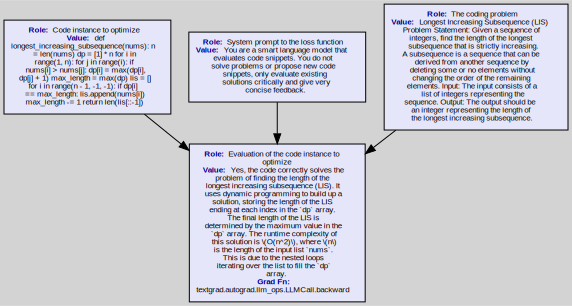

In [11]:
# Let's visualize our computation graph.
loss.generate_graph()

In [12]:
# Let's look at the gradients!
loss.backward()
print(code.gradients)

INFO:textgrad:_backward_through_llm prompt
INFO:textgrad:_backward_through_llm gradient


{Variable(value=To improve the code instance for the Longest Increasing Subsequence (LIS) problem, consider the following feedback:

1. **Optimize Runtime Complexity**: The current implementation has a time complexity of \(O(n^2)\), which can be improved. Consider using a more efficient algorithm with a time complexity of \(O(n \log n)\). This can be achieved by using a combination of dynamic programming and binary search. Specifically, you can maintain a list that represents the smallest possible tail value for all increasing subsequences of different lengths. Use binary search to find the position where the current element can replace an element in this list, ensuring the list remains sorted.

2. **Avoid Unnecessary Operations**: The current code constructs the actual subsequence in the `lis` list and then reverses it to calculate its length. Since the problem only requires the length of the LIS, constructing the subsequence is unnecessary. You can directly return the maximum value f

In [13]:
# Let's update the code
optimizer.step()

INFO:textgrad:TextualGradientDescent prompt for update
INFO:textgrad:TextualGradientDescent optimizer response
INFO:textgrad:TextualGradientDescent updated text


In [14]:
# Hopefully, we should get much better runtime!
longest_increasing_subsequence = run_function_in_interpreter(code.value)

start_time = time.time()
lis = longest_increasing_subsequence(nums)
end_time = time.time()

print(f"Longest Increasing Subsequence Length: {lis}")
print(f"Runtime: {end_time - start_time:.5f} seconds")

test_longest_increasing_subsequence(longest_increasing_subsequence)

Longest Increasing Subsequence Length: 181
Runtime: 0.00267 seconds
All test cases passed!


In [15]:
# Let's do one more iteration
optimizer.zero_grad()
loss = loss_fn(problem, code)
loss.backward()
optimizer.step()

INFO:textgrad:LLMCall function forward
INFO:textgrad:_backward_through_llm prompt
INFO:textgrad:_backward_through_llm gradient
INFO:textgrad:TextualGradientDescent prompt for update
INFO:textgrad:TextualGradientDescent optimizer response
INFO:textgrad:TextualGradientDescent updated text


In [16]:
longest_increasing_subsequence = run_function_in_interpreter(code.value)

start_time = time.time()
lis = longest_increasing_subsequence(nums)
end_time = time.time()

print(f"Longest Increasing Subsequence Length: {lis}")
print(f"Runtime: {end_time - start_time:.5f} seconds")

test_longest_increasing_subsequence(longest_increasing_subsequence)

Longest Increasing Subsequence Length: 181
Runtime: 0.00393 seconds
All test cases passed!


## Optimized code, much faster!

In [17]:
print(code.value)

from bisect import bisect_left

def longest_increasing_subsequence(nums):
    """
    Finds the length of the longest increasing subsequence in a list of integers.

    Parameters:
    nums (list of int): The input list of integers.

    Returns:
    int: The length of the longest increasing subsequence. Returns 0 if the input list is empty.
    """
    if not nums:
        return 0
    
    # List to store the smallest possible tail values for increasing subsequences
    subseq_tails = []
    
    for num in nums:
        # Find the position to update or extend the subseq_tails list
        pos = bisect_left(subseq_tails, num)
        if pos == len(subseq_tails):
            subseq_tails.append(num)
        else:
            subseq_tails[pos] = num
    
    return len(subseq_tails)
